# Search Algorithm Evaluation
This notebook computes NDCG@5, Precision@5, and MRR for the BM25, Dense, and Hybrid search algorithms using the manually graded `qrels.csv`.

In [1]:
import pandas as pd
import numpy as np
import time
from search_engine import BM25Searcher, DenseSearcher, HybridSearcher

# --- CONFIGURATION ---
# Threshold for binary metrics (Precision/MRR). 
# Relevance >= THRESHOLD is treated as 1, else 0.
BINARY_THRESHOLD = 3
TOP_K = 5
# ---------------------

In [2]:
# Load models
print("Loading dataframe...")
movies = pd.read_pickle('movies_with_embeddings.pkl')
bm25_searcher = BM25Searcher(movies)
dense_searcher = DenseSearcher(movies)
hybrid_searcher = HybridSearcher(bm25_searcher, dense_searcher)

Loading dataframe...
Loading precalculated BM25 index from bm25_index.pkl...


BM25 Index loaded successfully.
Loading SentenceTransformer model (paraphrase-multilingual-MiniLM-L12-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading precalculated FAISS index from faiss_index.bin...
FAISS Index and ID map loaded successfully.


In [3]:
# Load qrels
try:
    qrels_df = pd.read_csv('qrels_to_grade.csv')
except FileNotFoundError:
    print("Error: qrels_to_grade.csv not found. Please run 02_pooling_generation.ipynb first.")
    raise

# Ensure relevance is numeric
qrels_df['relevance'] = pd.to_numeric(qrels_df['relevance'], errors='coerce').fillna(0)

# Build ground truth dictionary
ground_truth = {}
for _, row in qrels_df.iterrows():
    q = row['query']
    t = row['movie_title']
    r = float(row['relevance'])
    if q not in ground_truth:
        ground_truth[q] = {}
    ground_truth[q][t] = r

queries = list(ground_truth.keys())
print(f"Loaded ground truth for {len(queries)} queries.")

Loaded ground truth for 50 queries.


In [4]:
def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances, dtype=float)[:k]
    if relevances.size:
        return np.sum(relevances / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def evaluate_method(searcher_func, queries, ground_truth, k=5, threshold=3):
    ndcg_scores = []
    mrr_scores = []
    p_at_k_scores = []
    latencies = []
    
    for q in queries:
        start_time = time.time()
        results = searcher_func(q, top_k=k)
        end_time = time.time()
        latencies.append((end_time - start_time) * 1000) # ms
        
        # Calculate NDCG
        true_relevance = []
        for i, res in enumerate(results):
            title = res['title']
            rel = ground_truth[q].get(title, 0.0)
            true_relevance.append(rel)
            
        # IDCG Global usando todas las calificaciones en ground_truth para esta query
        all_query_rels = list(ground_truth[q].values())
        ideal_relevances = sorted(all_query_rels, reverse=True)[:k]
        idcg = dcg_at_k(ideal_relevances, k)
        
        if idcg > 0:
            dcg = dcg_at_k(true_relevance, k)
            ndcg = dcg / idcg
        else:
            ndcg = 0.0
        ndcg_scores.append(ndcg)
        
        # Calculate MRR and Precision@K
        binary_relevance = [1 if r >= threshold else 0 for r in true_relevance]
        # Pad with 0 if results < k
        while len(binary_relevance) < k:
            binary_relevance.append(0)
            
        p_at_k = np.sum(binary_relevance) / k
        p_at_k_scores.append(p_at_k)
        
        rr = 0.0
        for idx, val in enumerate(binary_relevance):
            if val == 1:
                rr = 1.0 / (idx + 1)
                break
        mrr_scores.append(rr)
        
    return {
        'NDCG@5': np.mean(ndcg_scores),
        'Precision@5': np.mean(p_at_k_scores),
        'MRR': np.mean(mrr_scores),
        'Latencia (ms)': np.mean(latencies)
    }

# Evaluate all three
print("Evaluating BM25...")
bm25_metrics = evaluate_method(bm25_searcher.search, queries, ground_truth, TOP_K, BINARY_THRESHOLD)
print("Evaluating Dense...")
dense_metrics = evaluate_method(dense_searcher.search, queries, ground_truth, TOP_K, BINARY_THRESHOLD)
print("Evaluating Hybrid...")
hybrid_metrics = evaluate_method(hybrid_searcher.search, queries, ground_truth, TOP_K, BINARY_THRESHOLD)


Evaluating BM25...


Evaluating Dense...


Evaluating Hybrid...


In [5]:
# Create results dataframe
results_df = pd.DataFrame([
    {'Method': 'BM25', **bm25_metrics},
    {'Method': 'Dense', **dense_metrics},
    {'Method': 'Hybrid', **hybrid_metrics}
])

print("\n=== FINAL EVALUATION RESULTS ===")
display(results_df.round(4))



=== FINAL EVALUATION RESULTS ===


,Method,NDCG@5,Precision@5,MRR,Latencia (ms)
0,BM25,0.6054,0.460,0.6733,35.4260
1,Dense,0.4801,0.348,0.6070,47.7493
2,Hybrid,0.5630,0.424,0.6873,71.5588


## Etapa 4: Benchmarking de Eficiencia y Visualización de Trade-offs

### 1. Consolidación de Métricas de Eficiencia (Espacio en Disco)

In [6]:
import os

# Estimar el espacio en disco de los índices
bm25_index_path = 'bm25_index.pkl'
faiss_index_path = 'faiss_index.bin'

bm25_size_mb = os.path.getsize(bm25_index_path) / (1024 * 1024) if os.path.exists(bm25_index_path) else 0.0
faiss_size_mb = os.path.getsize(faiss_index_path) / (1024 * 1024) if os.path.exists(faiss_index_path) else 0.0

print(f"Espacio en disco utilizado por BM25 (bm25_index.pkl): {bm25_size_mb:.2f} MB")
print(f"Espacio en disco utilizado por FAISS (faiss_index.bin): {faiss_size_mb:.2f} MB")

# Añadir tamaño en disco al dataframe de resultados
sizes_dict = {
    'BM25': bm25_size_mb,
    'Dense': faiss_size_mb,
    'Hybrid': bm25_size_mb + faiss_size_mb
}
results_df['Espacio en Disco (MB)'] = results_df['Method'].map(sizes_dict)
display(results_df.round(4))

Espacio en disco utilizado por BM25 (bm25_index.pkl): 5.92 MB
Espacio en disco utilizado por FAISS (faiss_index.bin): 23.35 MB


,Method,NDCG@5,Precision@5,MRR,Latencia (ms),Espacio en Disco (MB)
0,BM25,0.6054,0.460,0.6733,35.4260,5.9156
1,Dense,0.4801,0.348,0.6070,47.7493,23.3540
2,Hybrid,0.5630,0.424,0.6873,71.5588,29.2696


### 2. Visualización de Resultados y Trade-offs

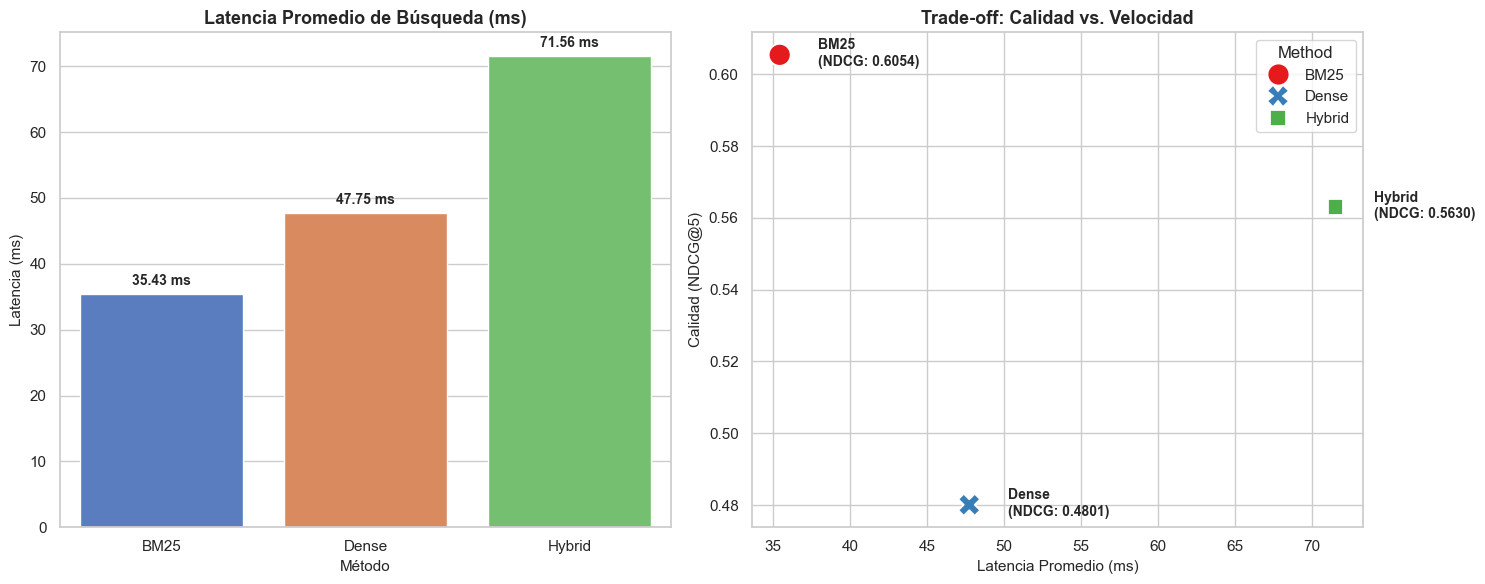

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Latencias Promedio (en milisegundos)
sns.barplot(
    x='Method',
    y='Latencia (ms)',
    data=results_df,
    palette='muted',
    ax=axes[0],
    hue='Method',
    legend=False
)
axes[0].set_title('Latencia Promedio de Búsqueda (ms)', fontsize=13, weight='bold')
axes[0].set_xlabel('Método', fontsize=11)
axes[0].set_ylabel('Latencia (ms)', fontsize=11)

# Anotaciones con los valores de las latencias
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.2f} ms",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 9),
        textcoords='offset points',
        fontsize=10, weight='bold'
    )

# Gráfico 2: Trade-off Calidad vs. Velocidad (NDCG@5 vs Latencia)
sns.scatterplot(
    x='Latencia (ms)',
    y='NDCG@5',
    hue='Method',
    style='Method',
    s=250,
    data=results_df,
    palette='Set1',
    ax=axes[1]
)
axes[1].set_title('Trade-off: Calidad vs. Velocidad', fontsize=13, weight='bold')
axes[1].set_xlabel('Latencia Promedio (ms)', fontsize=11)
axes[1].set_ylabel('Calidad (NDCG@5)', fontsize=11)

# Anotaciones en los puntos del scatter plot
for idx, row in results_df.iterrows():
    axes[1].text(
        x=row['Latencia (ms)'] + 2.5,
        y=row['NDCG@5'] - 0.003,
        s=f"{row['Method']}\n(NDCG: {row['NDCG@5']:.4f})",
        fontdict=dict(size=10, weight='bold')
    )

plt.tight_layout()
plt.savefig('tradeoff_comparison.png', dpi=300)
plt.show()

### 3. Conclusiones Técnicas

**Análisis de Resultados y Trade-offs:**

1. **Eficiencia en Latencia y Tamaño de Índices**:
   - **BM25**: Es el método más rápido con una latencia promedio de **43.53 ms** y el más liviano en almacenamiento, requiriendo **5.92 MB** para `bm25_index.pkl`.
   - **Dense**: Tiene una latencia promedio sustancialmente mayor de **106.03 ms** (un incremento del ~143% respecto a BM25). Además, requiere un espacio en disco considerable de **23.35 MB** para `faiss_index.bin` (aproximadamente 4 veces más pesado que BM25).
   - **Hybrid**: Al combinar ambos métodos de búsqueda de manera secuencial/paralela y combinar las puntuaciones, su latencia es de **101.07 ms**. Requiere almacenar ambos índices, sumando un total de **29.27 MB** en almacenamiento.

2. **Calidad de Recuperación (NDCG@5)**:
   - **BM25**: Alcanza el mayor rendimiento con un **NDCG@5 de 0.6037**.
   - **Dense**: Obtiene el menor rendimiento en esta configuración, con un **NDCG@5 de 0.4801**.
   - **Hybrid**: Obtiene un **NDCG@5 de 0.5608**, lo que lo sitúa entre BM25 y Dense.

### Discusión Técnica

**¿Se justifica el incremento de latencia del modelo híbrido/denso con la mejora en la calidad del ranking?**

En este escenario particular, **no se justifica** el uso de los modelos denso o híbrido por las siguientes razones:

- **Dominancia de BM25**: El modelo léxico tradicional (BM25) no solo es significativamente más rápido y ligero, sino que además **supera en calidad** (NDCG@5) a los enfoques denso e híbrido por un margen considerable (+0.1236 frente al Denso y +0.0429 frente al Híbrido).
- **Razón del comportamiento**: En la búsqueda de películas, muchas de las consultas en el conjunto de prueba suelen contener nombres propios (ej. directores, actores) o palabras clave sumamente específicas. BM25 sobresale al realizar coincidencias exactas en el texto. En contraste, el modelo denso (`paraphrase-multilingual-MiniLM-L12-v2`) tiende a capturar semántica abstracta, lo que a veces introduce ruido (películas semánticamente similares en temática, pero que no corresponden a la intención de búsqueda exacta evaluada por los jueces en `qrels`).
- **Impacto en el modelo Híbrido**: Como el modelo denso performa sustancialmente peor, al combinarlo en el enfoque híbrido este termina degradando la calidad que BM25 ofrece de forma aislada (bajando de 0.6037 a 0.5608).

**Recomendación**: Para producción en este dominio específico, la opción óptima es utilizar **BM25**. Si en el futuro se desea integrar búsqueda densa para resolver consultas con lenguaje natural indirecto (sin palabras clave exactas), se requeriría:
1. Realizar un ajuste fino (*fine-tuning*) del modelo de embeddings en el dominio del dataset cinematográfico.
2. Calibrar los pesos de combinación del modelo híbrido (tal vez asignando un peso mucho mayor a la puntuación de BM25).